### 1. Generate the $n(z)$ ensemble 

In [33]:
# Necessary imports #

# General #

import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from scipy.stats import gaussian_kde
from copy import deepcopy
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)
import sys
import os

import euclidlib as el
import seaborn as sns

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(repo_root)

# Gaussian processes

import matplotlib.pyplot as plt

from binz.run_gp import build_gp_nz 

import matplotlib as mpl 
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.serif'] = "Times New Roman"
mpl.rcParams['text.usetex'] = True

In [34]:
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

In [35]:
# Load in the DR1 n(z) 
zs = np.linspace(1e-4, 3, 100)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

In [36]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def generate_bin1_ensemble(
    N_ens=5,
    z_lo=0.001,
    z_hi=6,
    N_z=3001,
    mean_shift_sigma=0.01,
    width_shift_sigma=0.02,
    shape_noise_sigma=0.07,
    smooth_scale=3,
    nz = dndz_she_norm[1]
):
    """
    Generate an ensemble of n(z) realisations for the FIRST bin only:
        z ∈ [0.001, 0.42]
    using small shifts + smooth perturbations.
    """

    # ---------------------------
    # 1. Grid + base bin n(z)
    # ---------------------------
    z = np.linspace(z_lo, z_hi, N_z)
    nz /= np.trapezoid(nz, z)        # ensure norm within [0, 3] part
    nz_bin = nz.copy()               # for first bin, that's it

    # ---------------------------
    # Build ensemble
    # ---------------------------
    ensemble = []

    z_mean = np.trapezoid(z * nz_bin, z)

    for _ in range(N_ens):

        # Mean shift
        dz = np.random.normal(0, mean_shift_sigma) * z_mean
        z_shift = np.clip(z + dz, z_lo, z_hi)

        # Width/stretch shift
        width = 1 + np.random.normal(0, width_shift_sigma)
        z_stretch = z_mean + width * (z_shift - z_mean)
        z_stretch = np.clip(z_stretch, z_lo, z_hi)

        # Smooth random shape fluctuation
        noise = np.random.normal(0, shape_noise_sigma, N_z)
        noise_smooth = gaussian_filter1d(noise, smooth_scale)
        nz_pert = nz_bin * (1 + noise_smooth)
        nz_pert = np.clip(nz_pert, 1e-12, None)

        # Interpolate to shifted grid
        nz_new = np.interp(z, z_stretch, nz_pert, left=0, right=0)

        # Normalise inside the bin
        nz_new /= np.trapezoid(nz_new, z)

        ensemble.append(nz_new)

    return z, np.array(ensemble)

In [37]:
# Creating a list of plausible n(z) realizations

z_ens_list, nz_ensemble_list = zip(*[
    generate_bin1_ensemble(
        N_ens=200, 
        nz=dndz_she_norm[i], 
        N_z=3001,
        mean_shift_sigma=0.02,
        width_shift_sigma=0.02,
        shape_noise_sigma=0.05
    )
    for i in range(1, 7)
])

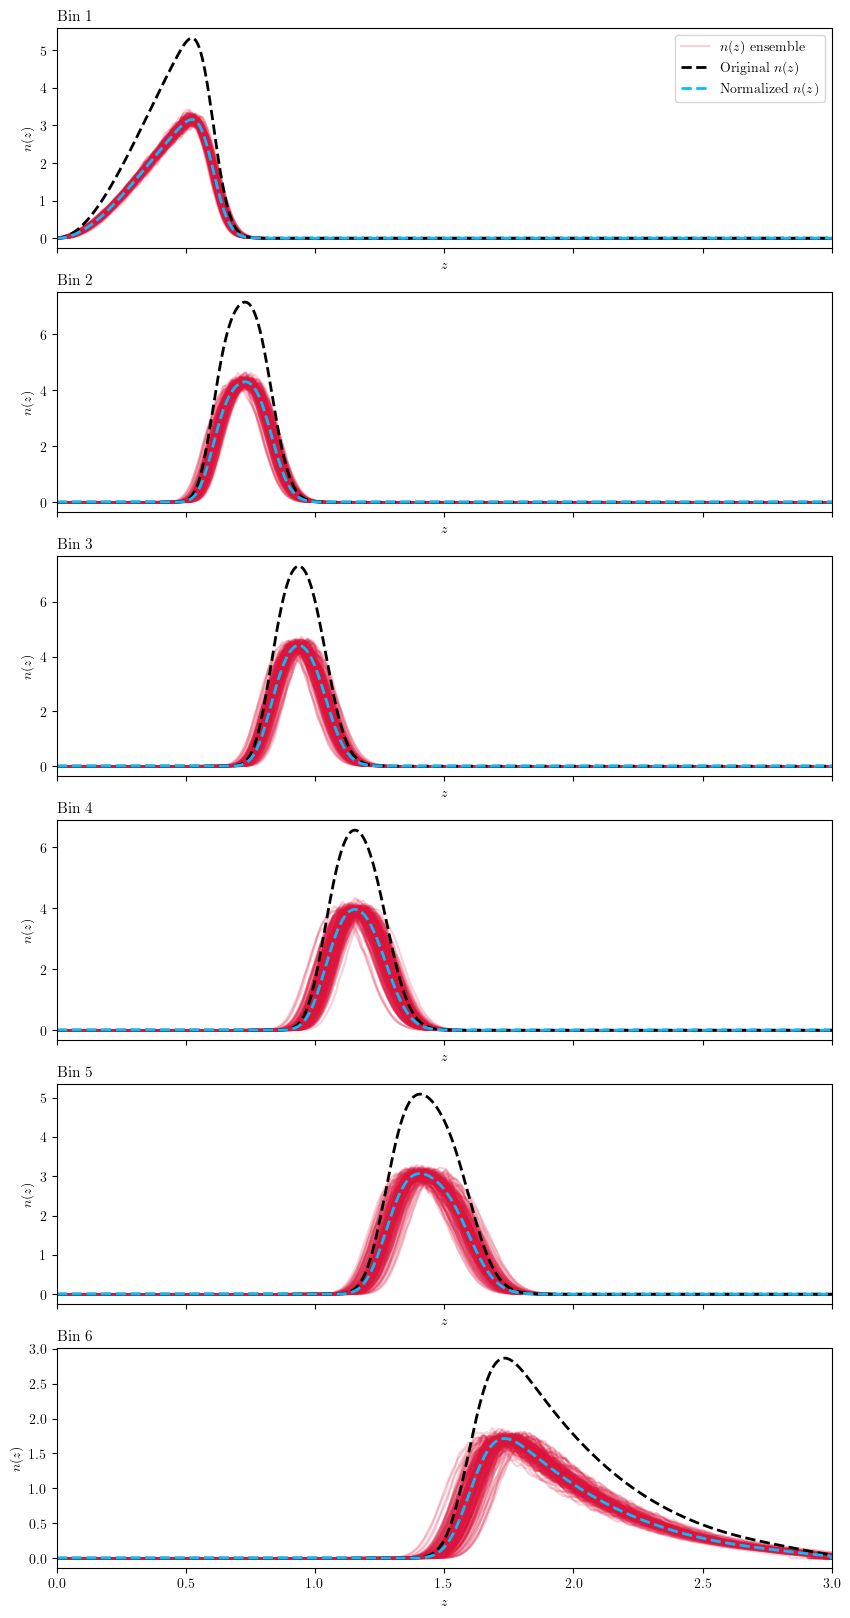

In [38]:
z_grid = z_ens_list[0]

fig, axes = plt.subplots(6, 1, figsize=(10,20), sharex=True)
axes = axes.flatten()
for i in range(len(nz_ensemble_list)):
    nz_ens = nz_ensemble_list[i]
    for j, nz in enumerate(nz_ens):
        if i == 0 and j == 0:
            axes[i].plot(z_grid, nz, color='crimson', alpha=0.2, label='$n(z)$ ensemble')
        else:
            axes[i].plot(z_grid, nz, color='crimson', alpha=0.2)
        
    axes[i].set_xlim(0, 3)
    axes[i].set_title(f"Bin {i+1}", loc="left", fontsize=11)
    axes[i].set_xlabel("$z$")
    axes[i].set_ylabel("$n(z)$")
    axes[i].plot(z_nz, nz_heracles[i+1], linestyle='--', lw=2, c='black', label='Original $n(z)$')
    axes[i].plot(z_nz, dndz_she_norm[i+1], linestyle='--', lw=2, c='deepskyblue', label='Normalized $n(z)$')
axes[0].legend()

### 2. The Gaussian process framework

In [39]:
# -----------------------------
# Utilities
# -----------------------------
def x_log1p(z, zmax):
    """Map z to x in [0,1] using log(1+z)."""
    return np.log1p(z) / np.log1p(zmax)

def normalize_nz(z, nz): 
    """
    Normalize the n(z)
    """
    area = np.trapezoid(nz, z)
    area = area if area > 0 else np.finfo(float).tiny
    return nz / area

def kernel_fixed(kernel_class, amp, ell, nu=1.5, amp_bounds=(1e-6, 10.0)):
    """
    Kernel with fixed length-scale ell, fixed (or bounded) amplitude amp.
    We keep optimizer=None, so amp and ell are not learned during GP fitting.
    """
    if kernel_class is Matern:
        return C(amp, amp_bounds) * Matern(length_scale=ell, nu=nu, length_scale_bounds="fixed")
    else:
        return C(amp, amp_bounds) * RBF(length_scale=ell, length_scale_bounds="fixed")

In [40]:
def reconstruct_nz_from_nodes_gp_square(
    z_pred,
    z_nodes,
    theta_nodes,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0,                 # <-- set 0 for interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False

):
    """
    This is the "inferred by the nodes" GP:
      Train on (zmin,0), (z_nodes, theta_nodes), (zmax,0).
      Predict on z_pred.

    IMPORTANT:
    - Do NOT clip/renormalize here if you want the GP mean to pass through nodes.
    - If you need positivity/normalization, do it in the node parameterization
      (e.g., sample log-theta) or use a log-GP model.
    """
    zmin, zmax = z_bounds
    z_pred = np.asarray(z_pred, float)    
    z_nodes = np.atleast_1d(np.asarray(z_nodes, dtype=float))
    theta_nodes = np.atleast_1d(np.asarray(theta_nodes, dtype=float))
    z_train = np.concatenate(([zmin], z_nodes, [zmax]))
    y_train_squareroot = np.concatenate(([0.0], np.sqrt(theta_nodes), [0.0]))


    X_train = x_log1p(z_train, zmax).reshape(-1, 1)
    X_pred  = x_log1p(z_pred, zmax).reshape(-1, 1)

    kernel = kernel_fixed(kernel_class, amp=amp, ell=corr_len, nu=nu, amp_bounds=(1e-6, 10.0))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=False,
        alpha=float(alpha),
        copy_X_train=False,
        random_state=0,
    )
    gp.fit(X_train, y_train_squareroot)

    if return_std:
        y_pred_squareroot, y_std = gp.predict(X_pred, return_std=True)
        y_pred = y_pred_squareroot**2
        return y_pred, y_std, gp
    else:
        y_pred_squareroot = gp.predict(X_pred, return_std=False)
        y_pred = y_pred_squareroot**2
        return y_pred
    
def reconstruct_all_bins_square(
    z_pred,
    z_nodes_all_bins,
    n_nodes_all_bins,            # list of arrays, each shape (M,)
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- use 0.0 if you want interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False
):
    """
    Decode all bins at once: returns list of n_b(z_pred).
    If return_std=True, returns list of (mean,std) per bin.
    """
    out = {}
    for b, z_node in enumerate(z_nodes_all_bins):
        if return_std:
            mean, std, _ = reconstruct_nz_from_nodes_gp_square(
                z_pred=z_pred,
                z_nodes=z_node,
                theta_nodes=n_nodes_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=True
            )
            out[b+1] = (mean, std)
        else:
            nz = reconstruct_nz_from_nodes_gp_square(
                z_pred=z_pred,
                z_nodes=z_node,
                theta_nodes=n_nodes_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=False
            )
            out[b+1] = nz
    return out

In [41]:
# Define parameters for GP reconstruction #

z_meds = []   # positions of median redshift for each bin
n_meds = []   # height of n(z) at median redshift for each bin

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds.append(z_med)
    n_meds.append(n_med)

corr_len = 0.03                                # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
z_nodes = []
n_nodes = []
for z_node, n_node in zip(z_meds, n_meds):
    z_node_array = np.array([z_node])
    n_node_array = np.array([n_node])
    z_nodes.append(z_node_array)
    n_nodes.append(n_node_array)


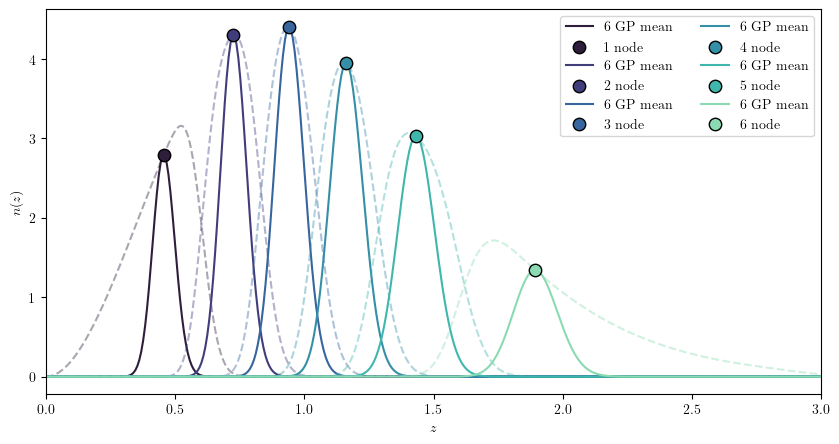

In [42]:
# GP reconstruction and plotting of results #

# Perform GP reconstruction #
predictions = reconstruct_all_bins_square(z_pred, z_meds, n_meds, z_bounds, corr_len, 0.04, alpha, kernel_class, nu)

# Plot GP reconstruction results #
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred = predictions[j+1]
    X_train, y_train = z_meds[j], n_meds[j]

    ax.plot(z_pred, y_pred, color=palette[j], label=f"{key} GP mean")
    #ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
    #                color=palette[j], alpha=0.2)

    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)
plt.show()

### 3. Implementing the normalising flow

3.1 Finding the training data for the flow for 3 training nodes 

In [43]:
import numpy as np
from scipy import integrate


def initial_nodes_from_quantiles(z_grid, nz, M=5, qmin=0.05, qmax=0.95):
    cdf = integrate.cumulative_trapezoid(nz, z_grid, initial=0) # find the cdf for quantiles
    cdf /= cdf[-1] # normalise
    quantiles = np.linspace(qmin, qmax, M)
    x_init = np.interp(quantiles, cdf, z_grid) # x position of quantiles
    y_init = np.interp(x_init, z_grid, nz) # y position of quantiles    
    y_init = np.clip(y_init, 1e-8, None) # Avoid exactly zero values because we will optimise log(y)
    return x_init, y_init


# Example for a single realisation
x_init, y_init = initial_nodes_from_quantiles(z_grid, nz_ens[0], M=3)

print(x_init)
print(y_init)

[1.69229904 1.99095294 2.67764481]
[0.89477794 1.31542153 0.22944841]


In [44]:
from scipy.optimize import minimize


def fit_gp_parameters_to_nz(z_grid, nz, M=5, z_bounds=(0.0, 3.0), ell_init=0.03, amp=0.04, alpha=1e-8, kernel_class=RBF, nu=1.5, qmin=0.05, qmax=0.95, 
                            maxiter=1000):
    """
    This function fits the GP x-nodes, y-nodes, and correlation length to a single n(z) realisation from the ensemble
    """

    zmin, zmax = z_bounds
    x_init, y_init = initial_nodes_from_quantiles(z_grid, nz, M=M, qmin=qmin, qmax=qmax) # initial guess from quantile
    p0 = np.concatenate([x_init, np.log(y_init), [np.log(ell_init)]]) # initial param vector

    def objective(p): # loss function
        x_nodes = p[:M]
        log_y = p[M:2*M]
        log_ell = p[2*M]
        y_nodes = np.exp(log_y)
        ell = np.exp(log_ell)
        nz_gp = reconstruct_nz_from_nodes_gp_square(z_pred=z_grid, z_nodes=x_nodes, theta_nodes=y_nodes, z_bounds=z_bounds, corr_len=ell,
            amp=amp, alpha=alpha, kernel_class=kernel_class, nu=nu, return_std=False)

        # Integrated squared difference
        loss = np.trapezoid((nz - nz_gp)**2, z_grid)
        return loss

    # Determining the bounds in between which the minimiser will explore
    x_bounds = [(zmin + 1e-5, zmax - 1e-5) for _ in range(M)]
    y_max = max(np.max(nz) * 10.0, 1e-5)
    y_bounds = [(np.log(1e-8), np.log(y_max)) for _ in range(M)]
    ell_bounds = [(np.log(1e-3), np.log(0.5))]
    bounds = x_bounds + y_bounds + ell_bounds

    # Enforcing ordering on the x-nodes
    constraints = []
    min_dx=1e-3
    for i in range(M - 1):
        constraints.append({"type": "ineq", "fun": lambda p, i=i: p[i + 1] - p[i] - min_dx})

    # Mimimising the loss function
    result = minimize(objective, p0, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter": maxiter, "ftol": 1e-10, "disp": False})

    # Converting back to original parameters
    p = result.x
    x_nodes = p[:M]
    y_nodes = np.exp(p[M:2*M])
    ell = np.exp(p[2*M])

    GP_params = np.concatenate([x_nodes, y_nodes, [ell]])

    return GP_params, result

In [45]:
# Testing our fitting method on a single n(z) realisation

b = 1
z_grid = z_ens_list[b]
nz_ens = nz_ensemble_list[b]
nz = nz_ens[4]
GP_params, result = fit_gp_parameters_to_nz(z_grid=z_grid, nz=nz, M=3, z_bounds=(0.0, 3.0), ell_init=0.03, amp=0.04)
print(GP_params)

[0.60540922 0.7274617  0.8075023  3.01213828 4.10176487 2.29473886
 0.03179614]


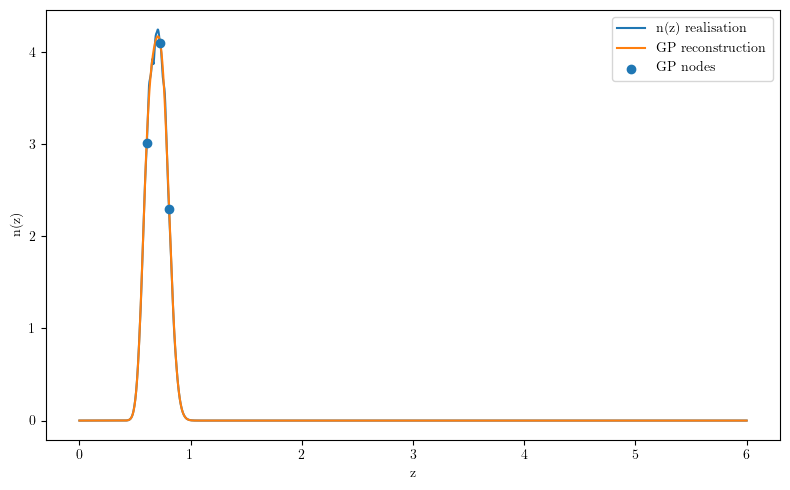

In [46]:
# Plotting the single fitting attempt

x_nodes = GP_params[:3]
y_nodes = GP_params[3:6]
ell = GP_params[6]
nz_reconstructed = reconstruct_nz_from_nodes_gp_square(z_pred=z_grid, z_nodes=x_nodes, theta_nodes=y_nodes, z_bounds=(0.0, 3.0), corr_len=ell, amp=0.04,
    alpha=0.0, kernel_class=RBF, nu=1.5)
plt.figure(figsize=(8, 5))
plt.plot(z_grid, nz, label="n(z) realisation")
plt.plot(z_grid, nz_reconstructed, label="GP reconstruction")
plt.scatter(x_nodes, y_nodes, label="GP nodes", zorder=3)
plt.xlabel("z")
plt.ylabel("n(z)")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# Now apply the method to the entire ensemble

def fit_gp_parameters_to_ensemble(z_grid, nz_ens, M=5, z_bounds=(0.0, 3.0), ell_init=0.03, amp=0.04, alpha=0.0, kernel_class=RBF, nu=1.5, qmin=0.05,
    qmax=0.95, maxiter=1000):
    GP_params_list = []
    results = []
    for k, nz in enumerate(nz_ens):
        print(f"Fitting realisation {k+1}/{len(nz_ens)}")
        params, result = fit_gp_parameters_to_nz(z_grid=z_grid, nz=nz, M=M, z_bounds=z_bounds, ell_init=ell_init, amp=amp, alpha=alpha, 
                                                 kernel_class=kernel_class, nu=nu, qmin=qmin, qmax=qmax, maxiter=maxiter)
        GP_params_list.append(params)
        results.append(result)
    GP_params = np.stack(GP_params_list, axis=0)
    return GP_params, results

In [48]:
# Reconstruct and plot the fitted GP n(z)'s 

def reconstruct_ensemble_from_GP_params(z_grid, GP_params, z_bounds=(0.0, 3.0), amp=0.04, alpha=1e-8, kernel_class=RBF, nu=1.5):
    N_ens = GP_params.shape[0]
    M = (GP_params.shape[1] - 1) // 2
    nz_gp_ens = np.zeros((N_ens, len(z_grid)))
    for k in range(N_ens):
        x_nodes = GP_params[k, :M]
        y_nodes = GP_params[k, M:2*M]
        ell = GP_params[k, 2*M]
        nz_gp_ens[k] = reconstruct_nz_from_nodes_gp_square(z_pred=z_grid, z_nodes=x_nodes, theta_nodes=y_nodes, z_bounds=z_bounds,
                                                           corr_len=ell, amp=amp, alpha=alpha, kernel_class=kernel_class, nu=nu)
    return nz_gp_ens

In [49]:
# Fitting the GP hyperparameters to all realisations for all bins. For 50 realisations, 6 bins, and 7 GP params, the final array has shape 6 x 50 x 7.

GP_params_all_bins = []
fit_results_all_bins = []
nz_gp_ens_all_bins = []

for b in range(len(nz_ensemble_list)):
    print(f"Fitting bin {b+1}/{len(nz_ensemble_list)}")
    z_grid = z_ens_list[b]
    nz_ens = nz_ensemble_list[b]
    GP_params, fit_results = fit_gp_parameters_to_ensemble(z_grid=z_grid, nz_ens=nz_ens, M=3, z_bounds=(0.0, 3.0), ell_init=0.03, amp=0.04, alpha=1e-8,
                                                           kernel_class=RBF, nu=1.5, qmin=0.05, qmax=0.95, maxiter=1000)
    nz_gp_ens = reconstruct_ensemble_from_GP_params(z_grid=z_grid, GP_params=GP_params, z_bounds=(0.0, 3.0), amp=0.04, alpha=1e-8,
                                                     kernel_class=RBF, nu=1.5)
    GP_params_all_bins.append(GP_params)
    fit_results_all_bins.append(fit_results)
    nz_gp_ens_all_bins.append(nz_gp_ens)

Fitting bin 1/6
Fitting realisation 1/200
Fitting realisation 2/200
Fitting realisation 3/200
Fitting realisation 4/200
Fitting realisation 5/200
Fitting realisation 6/200
Fitting realisation 7/200
Fitting realisation 8/200
Fitting realisation 9/200
Fitting realisation 10/200
Fitting realisation 11/200
Fitting realisation 12/200
Fitting realisation 13/200
Fitting realisation 14/200
Fitting realisation 15/200
Fitting realisation 16/200
Fitting realisation 17/200
Fitting realisation 18/200
Fitting realisation 19/200
Fitting realisation 20/200
Fitting realisation 21/200
Fitting realisation 22/200
Fitting realisation 23/200
Fitting realisation 24/200
Fitting realisation 25/200
Fitting realisation 26/200
Fitting realisation 27/200
Fitting realisation 28/200
Fitting realisation 29/200
Fitting realisation 30/200
Fitting realisation 31/200
Fitting realisation 32/200
Fitting realisation 33/200
Fitting realisation 34/200
Fitting realisation 35/200
Fitting realisation 36/200
Fitting realisation 3

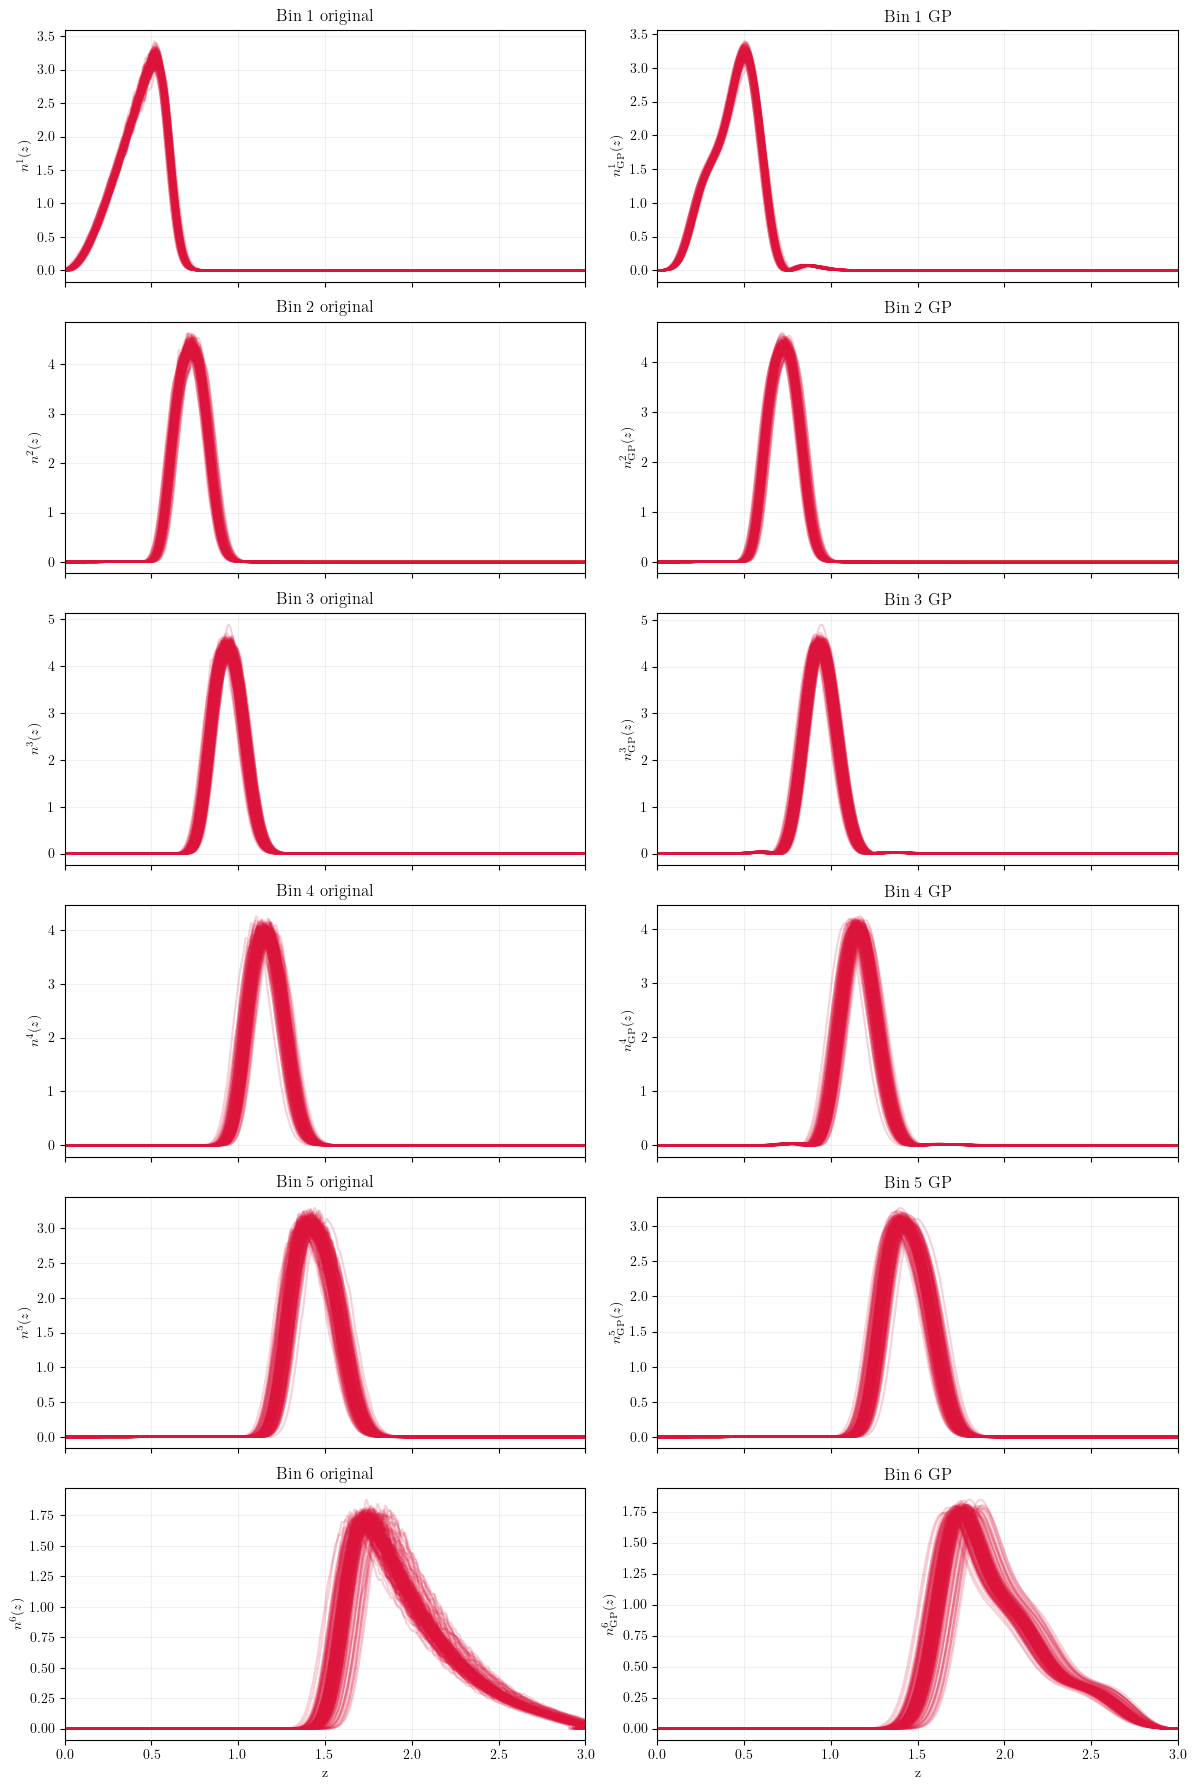

In [70]:
fig, axes = plt.subplots(6, 2, figsize=(12, 18), sharex=True)

for b in range(6):
    z_grid = z_ens_list[b]
    nz_ens = nz_ensemble_list[b]
    nz_gp_ens = nz_gp_ens_all_bins[b]

    for k in range(len(nz_ens)):
        axes[b, 0].plot(z_grid, nz_ens[k], color="crimson", alpha=0.2)
        axes[b, 1].plot(z_grid, nz_gp_ens[k], color="crimson", alpha=0.2)

    axes[b, 0].set_ylabel(r"$n^{" + str(b+1) + r"}(z)$")
    axes[b, 1].set_ylabel(r"$n^{" + str(b+1) + r"}_{\rm GP}(z)$")

    axes[b, 0].set_title(f"Bin {b+1} original")
    axes[b, 1].set_title(f"Bin {b+1} GP")

    axes[b, 0].grid(alpha=0.2)
    axes[b, 1].grid(alpha=0.2)

axes[-1, 0].set_xlabel("z")
axes[-1, 1].set_xlabel("z")
axes[-1, 0].set_xlim(0,3)
axes[-1, 1].set_xlim(0,3)

plt.tight_layout()

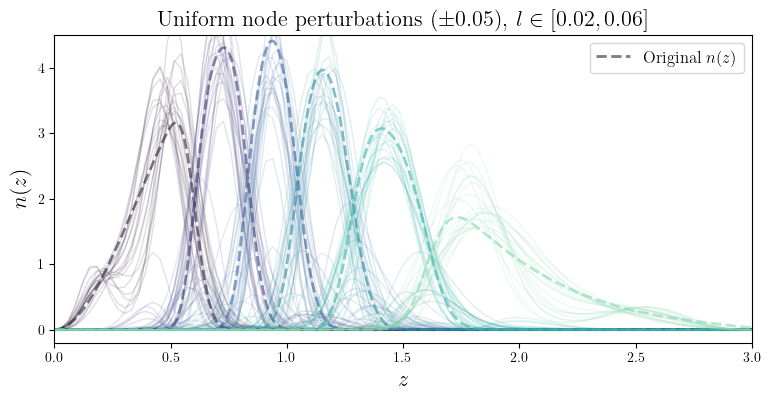

In [52]:
def resample_dndz_gp(gp_predictions, z_pred, zs):
    gp_predictions_norm = {}
    for key in gp_predictions.keys():
        gp_predictions_norm[key] = gp_predictions[key]/integrate.trapezoid(gp_predictions[key], z_pred[:,0])
    my_dndz = np.vstack(list(gp_predictions_norm.values())) 
    my_dndz_norm = np.zeros([len(gp_predictions_norm), len(zs)])
    for i in range(len(gp_predictions_norm)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

def compute_cdf_nodes(z_grid, nz_org, M=3, qmin=0.05, qmax=0.95):
    X_nodes = []
    Y_nodes = []   
    for key, nz in nz_org.items():
        cdf = integrate.cumulative_trapezoid(nz, z_grid, initial=0)
        cdf /= cdf[-1]
        z_peak = z_grid[np.argmax(nz)] # one node always at the peak
        if M > 1: # others at quantiles
            quantiles = np.linspace(qmin, qmax, M)
            x_nodes = np.interp(quantiles, cdf, z_grid)
            x_nodes[M//2] = z_peak
        else:
            x_nodes = np.array([z_peak])
        x_nodes = np.sort(x_nodes)
        y_nodes = np.interp(x_nodes, z_grid, nz)
        X_nodes.append(x_nodes)
        Y_nodes.append(y_nodes)
    return X_nodes, Y_nodes
x_nodes_all, y_nodes_all = compute_cdf_nodes(z_nz, dndz_she_norm, 3)
n_samples = 20
delta = 0.05
rng = np.random.default_rng()
fig, ax = plt.subplots(1, figsize=(9, 4))
palette = sns.color_palette("mako", 6)
z_pred_res = z_pred.reshape(-1, 1)

for j, nz in enumerate(n_meds):
    ax.plot(
        z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.6, lw=2,
        label="Original $n(z)$" if j == 0 else None
    )
    for s in range(n_samples):
        x_sample = np.array(x_nodes_all[j]) + rng.uniform(-delta, delta, len(x_nodes_all[j]))
        y_sample = np.array(y_nodes_all[j]) + rng.uniform(-delta, delta, len(y_nodes_all[j]))
        order = np.argsort(x_sample)
        x_sample = x_sample[order]
        y_sample = y_sample[order]
        x_tmp = list(x_nodes_all)
        y_tmp = list(y_nodes_all)
        x_tmp[j] = x_sample
        y_tmp[j] = y_sample
        corr_len_sample = rng.uniform(0.05, 0.08)
        y_pred_sample = reconstruct_all_bins_square(
            z_pred, x_tmp, y_tmp, corr_len=corr_len_sample
        )
        y_pred_sample_norm =  resample_dndz_gp(y_pred_sample, z_pred_res, zs)
        ax.plot(
            zs, y_pred_sample_norm[j],
            color=palette[j], alpha=0.15, lw=1
        )
ax.set_xlabel(r"$z$", fontsize=16)
ax.set_ylabel(r"$n(z)$", fontsize=16)
ax.set_xlim(0, 3)
ax.set_ylim(-0.2, 4.5)
ax.set_title("Uniform node perturbations ($\\pm 0.05$), $l \\in [0.02, 0.06]$", fontsize=16)
ax.legend(loc="upper right", fontsize=12)

(6, 50, 7)


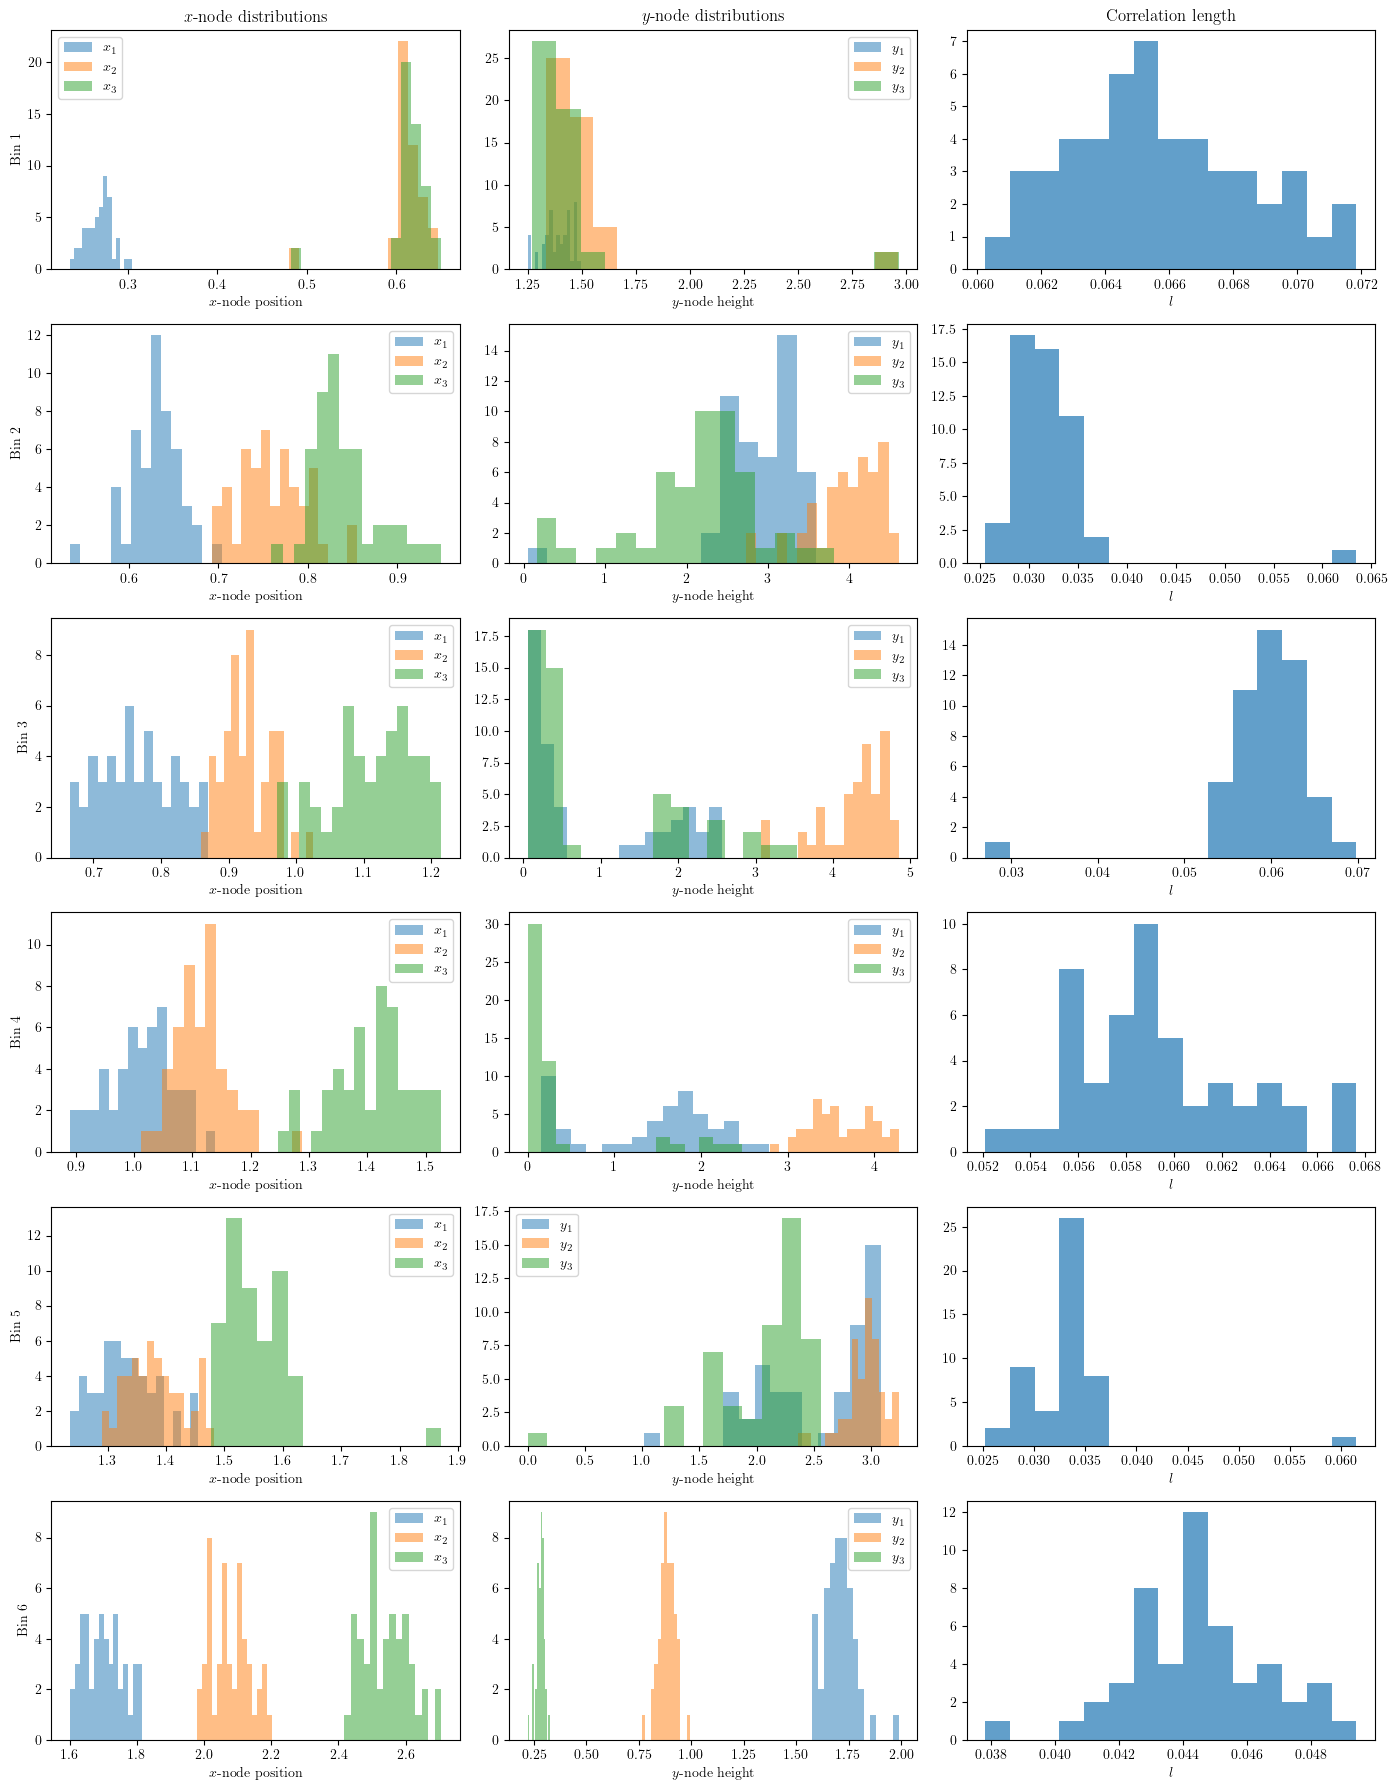

In [23]:
# Plotting the resulting distribution of GP params 

print(np.array(GP_params_all_bins).shape) # 6 bins, 50 realisations, 7 GP params (3 x-nodes, 3 y-nodes, 1 correlation length)
GP_params_array = np.array(GP_params_all_bins)

fig, axes = plt.subplots(6, 3, figsize=(14, 18))

for b in range(6):
    x_nodes = GP_params_array[b, :, :3]
    y_nodes = GP_params_array[b, :, 3:6]
    ell = GP_params_array[b, :, 6]

    for i in range(3):
        axes[b, 0].hist(x_nodes[:, i], bins=15, alpha=0.5, label=fr"$x_{i+1}$")
        axes[b, 1].hist(y_nodes[:, i], bins=15, alpha=0.5, label=fr"$y_{i+1}$")

    axes[b, 2].hist(ell, bins=15, alpha=0.7)

    axes[b, 0].set_ylabel(f"Bin {b+1}")
    axes[b, 0].legend()
    axes[b, 1].legend()

axes[0, 0].set_title("$x$-node distributions")
axes[0, 1].set_title("$y$-node distributions")
axes[0, 2].set_title("Correlation length")

for b in range(6):
    axes[b, 0].set_xlabel("$x$-node position")
    axes[b, 1].set_xlabel("$y$-node height")
    axes[b, 2].set_xlabel(r"$l$")

plt.tight_layout()

3.2 Training the normalising flow on the GP params 

In [53]:
from tqdm import tqdm
import torch 
from nflows.flows import Flow
from nflows.distributions import StandardNormal
from nflows.transforms import CompositeTransform, MaskedAffineAutoregressiveTransform

def ell_to_q(ell, ell_min=1e-2, ell_max=0.5): # apply transformation to impose physical bounds on the correlation length
    ell = np.asarray(ell)
    q = np.log((ell - ell_min) / (ell_max - ell))
    return q

def q_to_ell(q, ell_min=1e-2, ell_max=0.5):
    q = np.asarray(q)
    ell = ell_min + (ell_max - ell_min) / (1.0 + np.exp(-q))
    return ell

def y_to_q(y, y_min=1e-10, y_max=6):
    y = np.asarray(y)
    q = np.log((y - y_min) / (y_max - y))
    return q

def q_to_y(q, y_min=1e-10, y_max=6):
    q = np.asarray(q)
    y = y_min + (y_max - y_min) / (1.0 + np.exp(-q))
    return y

def normalizing_flow_per_bin(GP_params, M=3, n_layers=5, hidden_features=32, lr=1e-3, steps=3000, batch_size=128, val_fraction=0):

    U = GP_params.copy() # for 3 training nodes (i.e. M=3), U has shape (N_ens, 7)

 #   U[:, M:2*M] = np.log(np.clip(U[:, M:2*M], 1e-6, None)) # take the log of the y nodes (all rows, but only column M-1 to 2M-1)
 #   U[:, M:2*M] = y_to_q(U[:, M:2*M])
#    U[:, 2*M] = np.log(np.clip(U[:, 2*M], 1e-6, None)) # take the log of the correlation length (all rows, but only column 2M)
  #  U[:, 2*M] = ell_to_q(U[:, 2*M])
    mean = U.mean(axis=0)
    std = U.std(axis=0) + 1e-6
    U_norm = (U - mean) / std

    N = len(U_norm)
    idx = np.random.permutation(N)
    n_val = int(val_fraction * N)
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    train_data = torch.tensor(U_norm[train_idx], dtype=torch.float32)
    val_data = torch.tensor(U_norm[val_idx], dtype=torch.float32)

    n_params = U_norm.shape[1]
    base = StandardNormal(shape=[n_params]) # all flows begin as standard Gaussian vectors

    transforms = [] # here, invertible transformations will be stored
    for _ in range(n_layers): # autoregressive layers
        transforms.append(MaskedAffineAutoregressiveTransform(features=n_params, hidden_features=hidden_features)) # here, each layer learns a transformation

    transform = CompositeTransform(transforms) # combine layers into a single transformation
    flow = Flow(transform, base) # start with Gaussian base and apply transformation to get log_prob(y)

    optimizer = torch.optim.Adam(flow.parameters(), lr=lr) # optimize flow with Adam
    train_losses = []
    val_losses = []
    pbar = tqdm(range(steps), desc="Training flow", ncols=100)

    for step in pbar:
        batch_idx = torch.randint(0, train_data.shape[0], (min(batch_size, train_data.shape[0]),))
        batch = train_data[batch_idx]
        train_loss = -flow.log_prob(batch).mean()
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            val_loss = -flow.log_prob(val_data).mean()

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

#        pbar.set_postfix(train=f"{train_loss.item():.3f}", val=f"{val_loss.item():.3f}")

    #    if val_loss.item() < best_val_loss:
    #        best_val_loss = val_loss.item()
    #        best_state = {k: v.cpu().clone() for k, v in flow.state_dict().items()}
    #        patience_counter = 0
    #    else:
    #        patience_counter += 1
    #        if patience_counter >= patience:
    #            print(f"\nEarly stopping at step {step}")
    #            break

    #if best_state is not None:
    #    flow.load_state_dict(best_state)

    return flow, mean, std

In [54]:
flows = []
means = []
stds = []

for b in range(6):
    print(f"Training flow for bin {b+1}")
    flow_b, mean_b, std_b = normalizing_flow_per_bin(GP_params_all_bins[b], M=3)
    flows.append(flow_b)
    means.append(mean_b)
    stds.append(std_b)

Training flow for bin 1


Training flow: 100%|███████████████████████████████████████████| 3000/3000 [00:25<00:00, 119.49it/s]


Training flow for bin 2


Training flow: 100%|███████████████████████████████████████████| 3000/3000 [00:24<00:00, 123.95it/s]


Training flow for bin 3


...

Training flow: 100%|███████████████████████████████████████████| 3000/3000 [00:20<00:00, 145.17it/s]


Training flow for bin 5


Training flow: 100%|███████████████████████████████████████████| 3000/3000 [00:21<00:00, 136.60it/s]


Training flow for bin 6


Training flow: 100%|███████████████████████████████████████████| 3000/3000 [00:27<00:00, 107.87it/s]


In [22]:
x_bounds = [[0, 1.2], [0.3, 1.3], [0.5, 1.5], [0.6, 1.6], [0.7, 2.2], [1.2, 3]]
y_bounds = [[]]

def plot_all_bins(flows, means, stds, GP_params_all_bins, nz_ensemble_list, z_ens_list, z_pred, reconstruct_nz_from_nodes_gp_square, M):
    fig, axes = plt.subplots(len(flows), 2, figsize=(22, 4*len(flows)))
    skipped = 0
    for b in range(len(flows)):
        print(f"Plotting bin {b+1}")
        flow = flows[b] # flow for current bin
        mean = means[b]
        std = stds[b]
        GP_params = GP_params_all_bins[b] # GP params for current bin
        nz_ens = nz_ensemble_list[b] # n(z) ensemble for current bin
        z_grid = z_ens_list[b]

        ax_left = axes[b, 0]
        ax_right = axes[b, 1]
        U_flow_norm = flow.sample(200).detach().numpy()
        GP_flow = U_flow_norm * std + mean

        x_flow = GP_flow[:, :M]
        y_flow = GP_flow[:, M:2*M]
        ell_flow = GP_flow[:, 2*M]

        
        
        for i in range(len(GP_flow)): # plot each realisation
#            print(f"y-nodes: {y_flow[i]}, x-nodes: {x_flow[i]}, corr len: {ell_flow[i]}")
            if ell_flow[i] < 0 or np.any(y_flow[i] < 0):
                skipped += 1
                continue
            y_pred = reconstruct_nz_from_nodes_gp_square(z_pred, x_flow[i], y_flow[i], z_bounds=(0.0, 3.0), corr_len=ell_flow[i], amp=0.04, alpha=0.0,
                kernel_class=RBF, nu=1.5, return_std=False)
            ax_left.plot(z_pred, y_pred, color="crimson", alpha=0.2)
            ax_left.scatter(x_flow[i], y_flow[i], color="gray", marker=".", alpha=0.2)
        ax_left.set_xlim(x_bounds[b][0], x_bounds[b][1])
        ax_left.set_title(f"Bin {b+1}: Normalising Flow Prior Samples")
        ax_left.set_xlabel("$z$")
        ax_left.set_ylabel("$n(z)$")
        ax_left.set_ylim(0, np.max(y_pred+1))
        ax_left.legend(["GP reconstructions", "Nodes sampled from flow"])
        for i in range(nz_ens.shape[0]):
            ax_right.plot(z_grid, nz_ens[i], color="crimson", alpha=0.2, lw=0.8)
        ax_right.set_xlim(x_bounds[b][0], x_bounds[b][1])
        ax_right.set_title(f"Bin {b+1}: Ensemble Curves")
        ax_right.set_xlabel("$z$")
        ax_right.set_ylabel("$n(z)$")
        ax_right.set_ylim(0, np.max(y_pred+1))
    plt.tight_layout()
    return fig, skipped

In [32]:
fig, skipped_count = plot_all_bins(
    flows, means, stds,
    GP_params_all_bins, nz_ensemble_list, z_ens_list, z_pred,  reconstruct_nz_from_nodes_gp_square, 3)
print(f"Amount of realisations skipped: {skipped_count}")
#plt.savefig("/home/jipdebuck/plots_flow/flow_comparison_3.pdf")

NameError: name 'GP_params_all_bins' is not defined

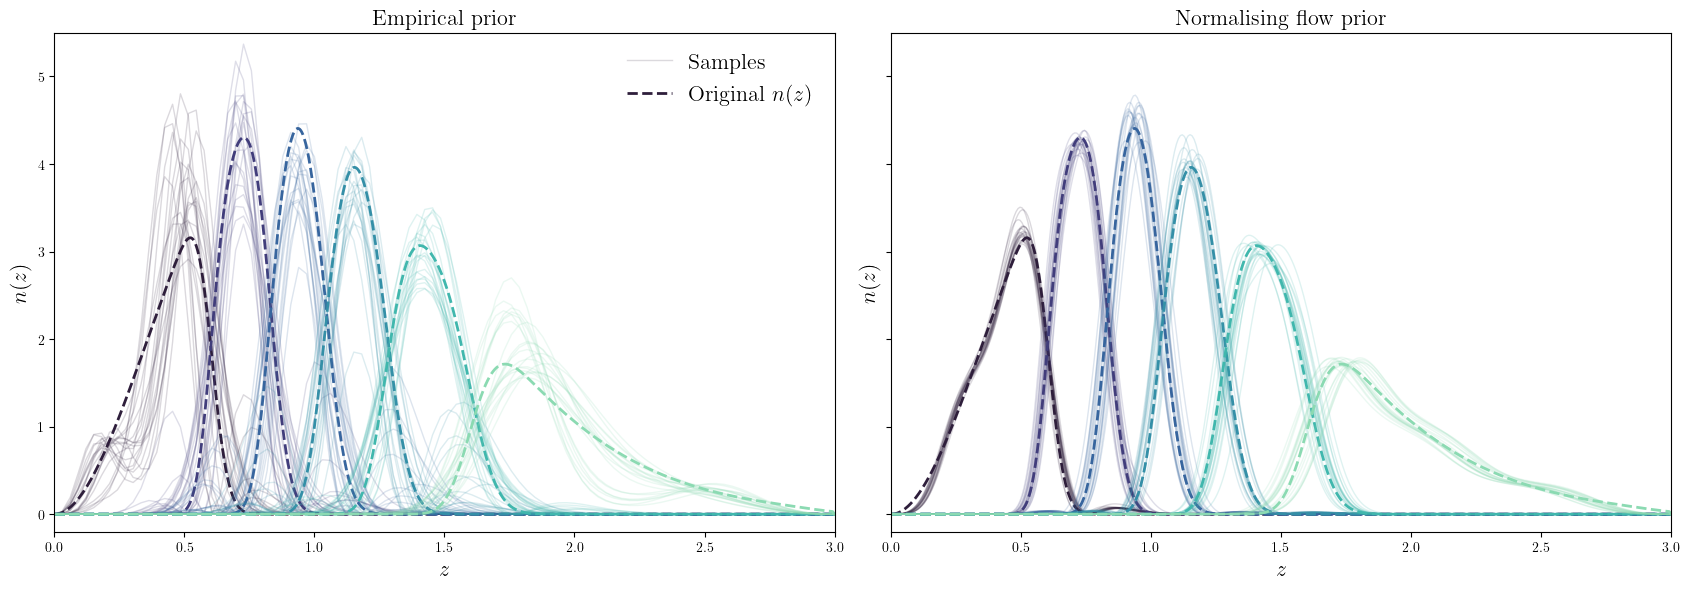

In [72]:
n_samples = 20

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)
palette = sns.color_palette("mako", 6)
z_pred_res = z_pred.reshape(-1, 1)

ax = axes[0]

for j, nz in enumerate(n_meds):
    

    for s in range(n_samples):
        x_sample = np.array(x_nodes_all[j]) + rng.uniform(-delta, delta, len(x_nodes_all[j]))
        y_sample = np.array(y_nodes_all[j]) + rng.uniform(-delta, delta, len(y_nodes_all[j]))
        order = np.argsort(x_sample)
        x_sample = x_sample[order]
        y_sample = y_sample[order]

        x_tmp = list(x_nodes_all)
        y_tmp = list(y_nodes_all)
        x_tmp[j] = x_sample
        y_tmp[j] = y_sample

        corr_len_sample = rng.uniform(0.05, 0.08)
        y_pred_sample = reconstruct_all_bins_square(
            z_pred, x_tmp, y_tmp, corr_len=corr_len_sample
        )
        y_pred_sample_norm = resample_dndz_gp(
            y_pred_sample, z_pred_res, zs
        )

        ax.plot(zs, y_pred_sample_norm[j], color=palette[j], alpha=0.17, lw=1, label='Samples' if j == 0 and s == 0 else None)
    ax.plot(
            z_nz, dndz_she_norm[j + 1], '--',
            color=palette[j], alpha=1, lw=2,
            label="Original $n(z)$" if j == 0 else None
        )

ax.set_xlabel(r"$z$", fontsize=16)
ax.set_ylabel(r"$n(z)$", fontsize=16)
ax.set_xlim(0, 3)
ax.set_ylim(-0.2, 4.5)
ax.set_title("Empirical prior", fontsize=16)
ax.legend(loc="upper right", fontsize=16, frameon=False)

ax = axes[1]

for b in range(len(flows)):
    flow = flows[b]
    mean = means[b]
    std = stds[b]

    U_flow_norm = flow.sample(n_samples).detach().numpy()
    GP_flow = U_flow_norm * std + mean

    x_flow = GP_flow[:, :3]
    y_flow = GP_flow[:, 3:2*3]
    ell_flow = GP_flow[:, 2*3]

    for i in range(len(GP_flow)):
        if ell_flow[i] < 0 or np.any(y_flow[i] < 0):
            continue

        y_pred = reconstruct_nz_from_nodes_gp_square(
            z_pred, x_flow[i], y_flow[i],
            z_bounds=(0.0, 3.0),
            corr_len=ell_flow[i],
            amp=0.04, alpha=0.0,
            kernel_class=RBF, nu=1.5,
            return_std=False
        )

        ax.plot(z_pred, y_pred, color=palette[b], alpha=0.17, lw=1)
    ax.plot(
            z_nz, dndz_she_norm[b + 1], '--',
            color=palette[b], alpha=1, lw=2
        )

ax.set_xlabel(r"$z$", fontsize=16)
ax.set_ylabel(r"$n(z)$", fontsize=16)
ax.set_xlim(0, 3)
ax.set_ylim(-0.2, 5.5)
ax.set_title("Normalising flow prior", fontsize=16)

plt.tight_layout()
plt.savefig('/home/jipdebuck/thesis_plots/nz_comparison_flow.pdf', bbox_inches='tight')

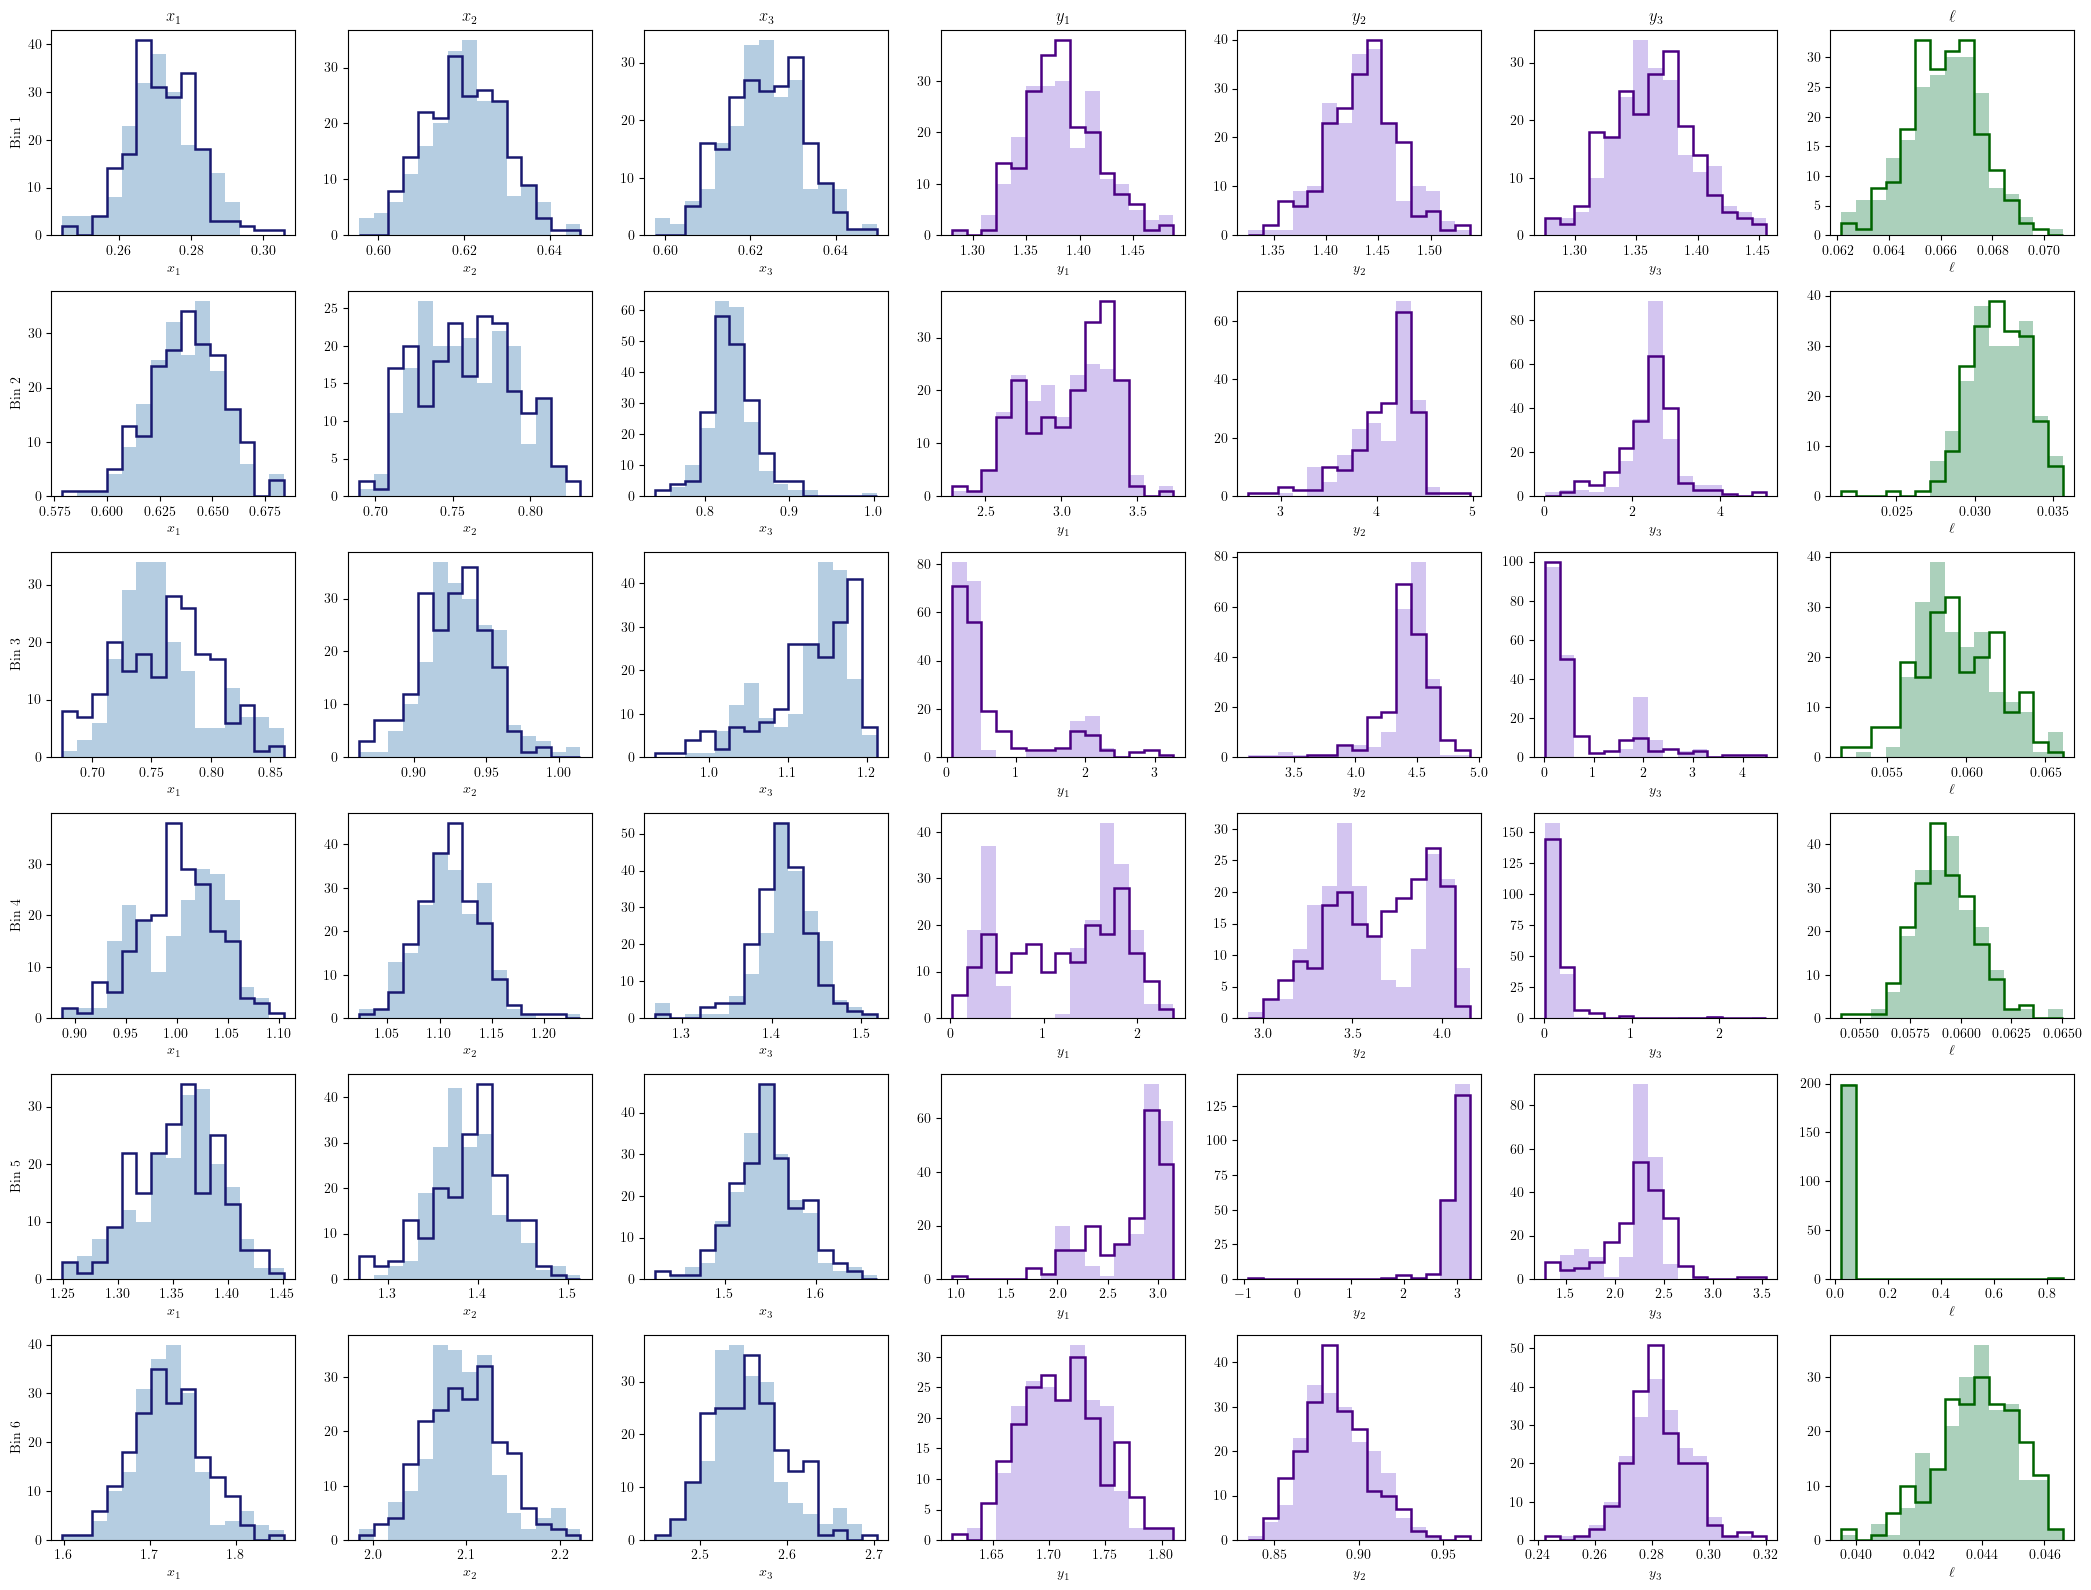

In [91]:
GP_params_array = np.array(GP_params_all_bins)

x_color = "steelblue"
x_dark = "midnightblue"
y_color = "mediumpurple"
y_dark = "indigo"
ell_color = "seagreen"
ell_dark = "darkgreen"

fig, axes = plt.subplots(6, 7, figsize=(21, 16))

for b in range(6):
    x_nodes = GP_params_array[b, :, :3]
    y_nodes = GP_params_array[b, :, 3:6]
    ell = GP_params_array[b, :, 6]

    flow_samples_norm = flows[b].sample(200).detach().numpy()
    flow_samples = flow_samples_norm * stds[b] + means[b]

    x_flow = flow_samples[:, :3]
    y_flow = flow_samples[:, 3:6]
    ell_flow = flow_samples[:, 6]



    for i in range(3):
        bins_x = np.histogram_bin_edges(np.concatenate([x_nodes[:, i], x_flow[:, i]]), bins=15)
        axes[b, i].hist(x_nodes[:, i], bins=bins_x, alpha=0.4, color=x_color)
        axes[b, i].hist(x_flow[:, i], bins=bins_x, histtype="step", linewidth=1.8, color=x_dark)
        axes[b, i].set_xlabel(fr"$x_{i+1}$")

    for i in range(3):
        bins_y = np.histogram_bin_edges(np.concatenate([y_nodes[:, i], y_flow[:, i]]), bins=15)
        axes[b, i+3].hist(y_nodes[:, i], bins=bins_y, alpha=0.4, color=y_color)
        axes[b, i+3].hist(y_flow[:, i], bins=bins_y, histtype="step", linewidth=1.8, color=y_dark)
        axes[b, i+3].set_xlabel(fr"$y_{i+1}$")

    bins_ell = np.histogram_bin_edges(np.concatenate([ell, ell_flow]), bins=15)
    axes[b, 6].hist(ell, bins=bins_ell, alpha=0.4, color=ell_color)
    axes[b, 6].hist(ell_flow, bins=bins_ell, histtype="step", linewidth=1.8, color=ell_dark)
    axes[b, 6].set_xlabel(r"$\ell$")

    axes[b, 0].set_ylabel(f"Bin {b+1}")

axes[0, 0].set_title("$x_1$")
axes[0, 1].set_title("$x_2$")
axes[0, 2].set_title("$x_3$")
axes[0, 3].set_title("$y_1$")
axes[0, 4].set_title("$y_2$")
axes[0, 5].set_title("$y_3$")
axes[0, 6].set_title("$\\ell$")

plt.tight_layout()
plt.savefig('/home/jipdebuck/plots_flow/distributions_2.pdf', bbox_inches='tight')

### PCA + normalising flow 

In [7]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.decomposition import PCA
from nflows.flows import Flow
from nflows.distributions import StandardNormal
from nflows.transforms import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform


def pca_normalizing_flow(nz_ensemble, n_components=4, n_layers=5, hidden_features=32, lr=1e-3, steps=3000, batch_size=128, val_fraction=0):
    # Each row is one plausible n(z), evaluated on the same redshift grid
    nz_ensemble = np.asarray(nz_ensemble)

    # PCA finds the main ways in which the full n(z) curves vary across the ensemble
    pca = PCA(n_components=n_components)
    A = pca.fit_transform(nz_ensemble)  # A contains the PCA coordinates of every reconstruction

    # Standardise the PCA coordinates so that the NF sees parameters with comparable scales
    mean = A.mean(axis=0)
    std = A.std(axis=0) + 1e-6
    A_norm = (A - mean) / std

    N = len(A_norm)
    idx = np.random.permutation(N)
    n_val = int(val_fraction * N)
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    train_data = torch.tensor(A_norm[train_idx], dtype=torch.float32)
    val_data = torch.tensor(A_norm[val_idx], dtype=torch.float32) if n_val > 0 else None

    n_params = n_components
    base = StandardNormal(shape=[n_params])  # The flow starts from a simple Gaussian and learns to transform it into the PCA distribution

    transforms = []
    for _ in range(n_layers):
        transforms.append(MaskedAffineAutoregressiveTransform(features=n_params, hidden_features=hidden_features))

    transform = CompositeTransform(transforms)  # Apply all learned transformations in sequence
    flow = Flow(transform, base)

    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    train_losses = []
    val_losses = []

    pbar = tqdm(range(steps), desc="Training PCA + NF", ncols=100)
    for step in pbar:
        batch_idx = torch.randint(0, train_data.shape[0], (min(batch_size, train_data.shape[0]),))
        batch = train_data[batch_idx]

        train_loss = -flow.log_prob(batch).mean()  # Maximum likelihood training: make plausible PCA coordinates have high probability
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        train_losses.append(train_loss.item())

        if val_data is not None:
            with torch.no_grad():
                val_loss = -flow.log_prob(val_data).mean()
            val_losses.append(val_loss.item())

    return flow, pca, mean, std, train_losses, val_losses


def evaluate_pca_nf_prior(nz_current, flow, pca, mean, std):
    nz_current = np.asarray(nz_current)

    if nz_current.ndim == 1:
        nz_current = nz_current[None, :]  # PCA expects a 2D array, even for one reconstruction

    A_current = pca.transform(nz_current)  # Express the current n(z) in the same coordinates learned from the training ensemble
    A_current_norm = (A_current - mean) / std  # Apply exactly the same standardisation used during training

    A_current_tensor = torch.tensor(A_current_norm, dtype=torch.float32)

    with torch.no_grad():
        log_prob = flow.log_prob(A_current_tensor)  # Joint log probability of the complete reconstruction in PCA space

    return log_prob.item()



In [26]:
flows = []
pcas = []
means = []
stds = []
train_losses = []
val_losses = []

for ensemble in nz_ensemble_list:
    flow, pca, mean, std, train_loss, val_loss = pca_normalizing_flow(
        ensemble,
        n_components=4,
        n_layers=5,
        hidden_features=32,
        lr=1e-3,
        steps=3000,
        batch_size=128,
        val_fraction=0
    )

    flows.append(flow)
    pcas.append(pca)
    means.append(mean)
    stds.append(std)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

Training PCA + NF: 100%|███████████████████████████████████████| 3000/3000 [00:16<00:00, 176.67it/s]


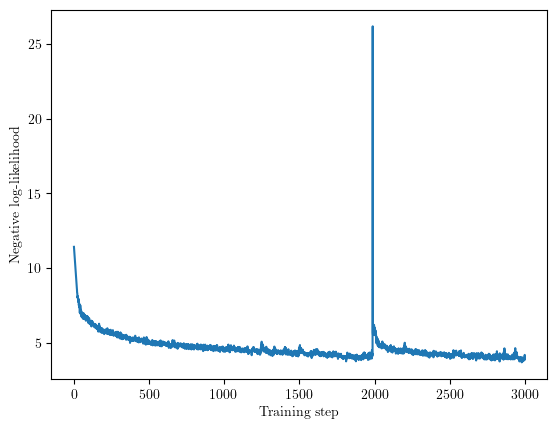

In [31]:
plt.plot(train_losses[0])
plt.xlabel("Training step")
plt.ylabel("Negative log-likelihood")
plt.show()

In [27]:
def sample_nz_from_flow(flow, pca, mean, std, n_samples=100):
    with torch.no_grad():
        samples_norm = flow.sample(n_samples).cpu().numpy()
    samples = samples_norm * std + mean
    nz_samples = pca.inverse_transform(samples)
    nz_samples = np.clip(nz_samples, 0, None)
    return nz_samples

In [28]:
def plot_all_bins_pca(flows, means, stds, pcas, nz_ensemble_list, z_ens_list):
    fig, axes = plt.subplots(len(flows), 2, figsize=(22, 4*len(flows)))
    for b in range(len(flows)):
        print(f"Plotting bin {b+1}")
        flow = flows[b]
        mean = means[b]
        std = stds[b]
        pca = pcas[b]
        nz_ens = nz_ensemble_list[b]
        z_grid = z_ens_list[b]
        ax_left = axes[b, 0]
        ax_right = axes[b, 1]
        U_flow_norm = flow.sample(200).detach().numpy()
        PCA_flow = U_flow_norm * std + mean
        nz_flow = pca.inverse_transform(PCA_flow)
        nz_flow = np.clip(nz_flow, 0, None)
        for i in range(len(nz_flow)):
            ax_left.plot(z_grid, nz_flow[i], color="crimson", alpha=0.2)
        ax_left.set_xlim(x_bounds[b][0], x_bounds[b][1])
        ax_left.set_title(f"Bin {b+1}: PCA + Normalising Flow Prior Samples")
        ax_left.set_xlabel("$z$")
        ax_left.set_ylabel("$n(z)$")
        ax_left.set_ylim(0, np.max(nz_flow + 1))
        ax_left.legend(["PCA + NF reconstructions"])
        for i in range(nz_ens.shape[0]):
            ax_right.plot(z_grid, nz_ens[i], color="crimson", alpha=0.2, lw=0.8)
        ax_right.set_xlim(x_bounds[b][0], x_bounds[b][1])
        ax_right.set_title(f"Bin {b+1}: Ensemble Curves")
        ax_right.set_xlabel("$z$")
        ax_right.set_ylabel("$n(z)$")
        ax_right.set_ylim(0, np.max(nz_flow + 1))
    plt.tight_layout()
    return fig

Plotting bin 1
Plotting bin 2
Plotting bin 3
Plotting bin 4
Plotting bin 5
Plotting bin 6


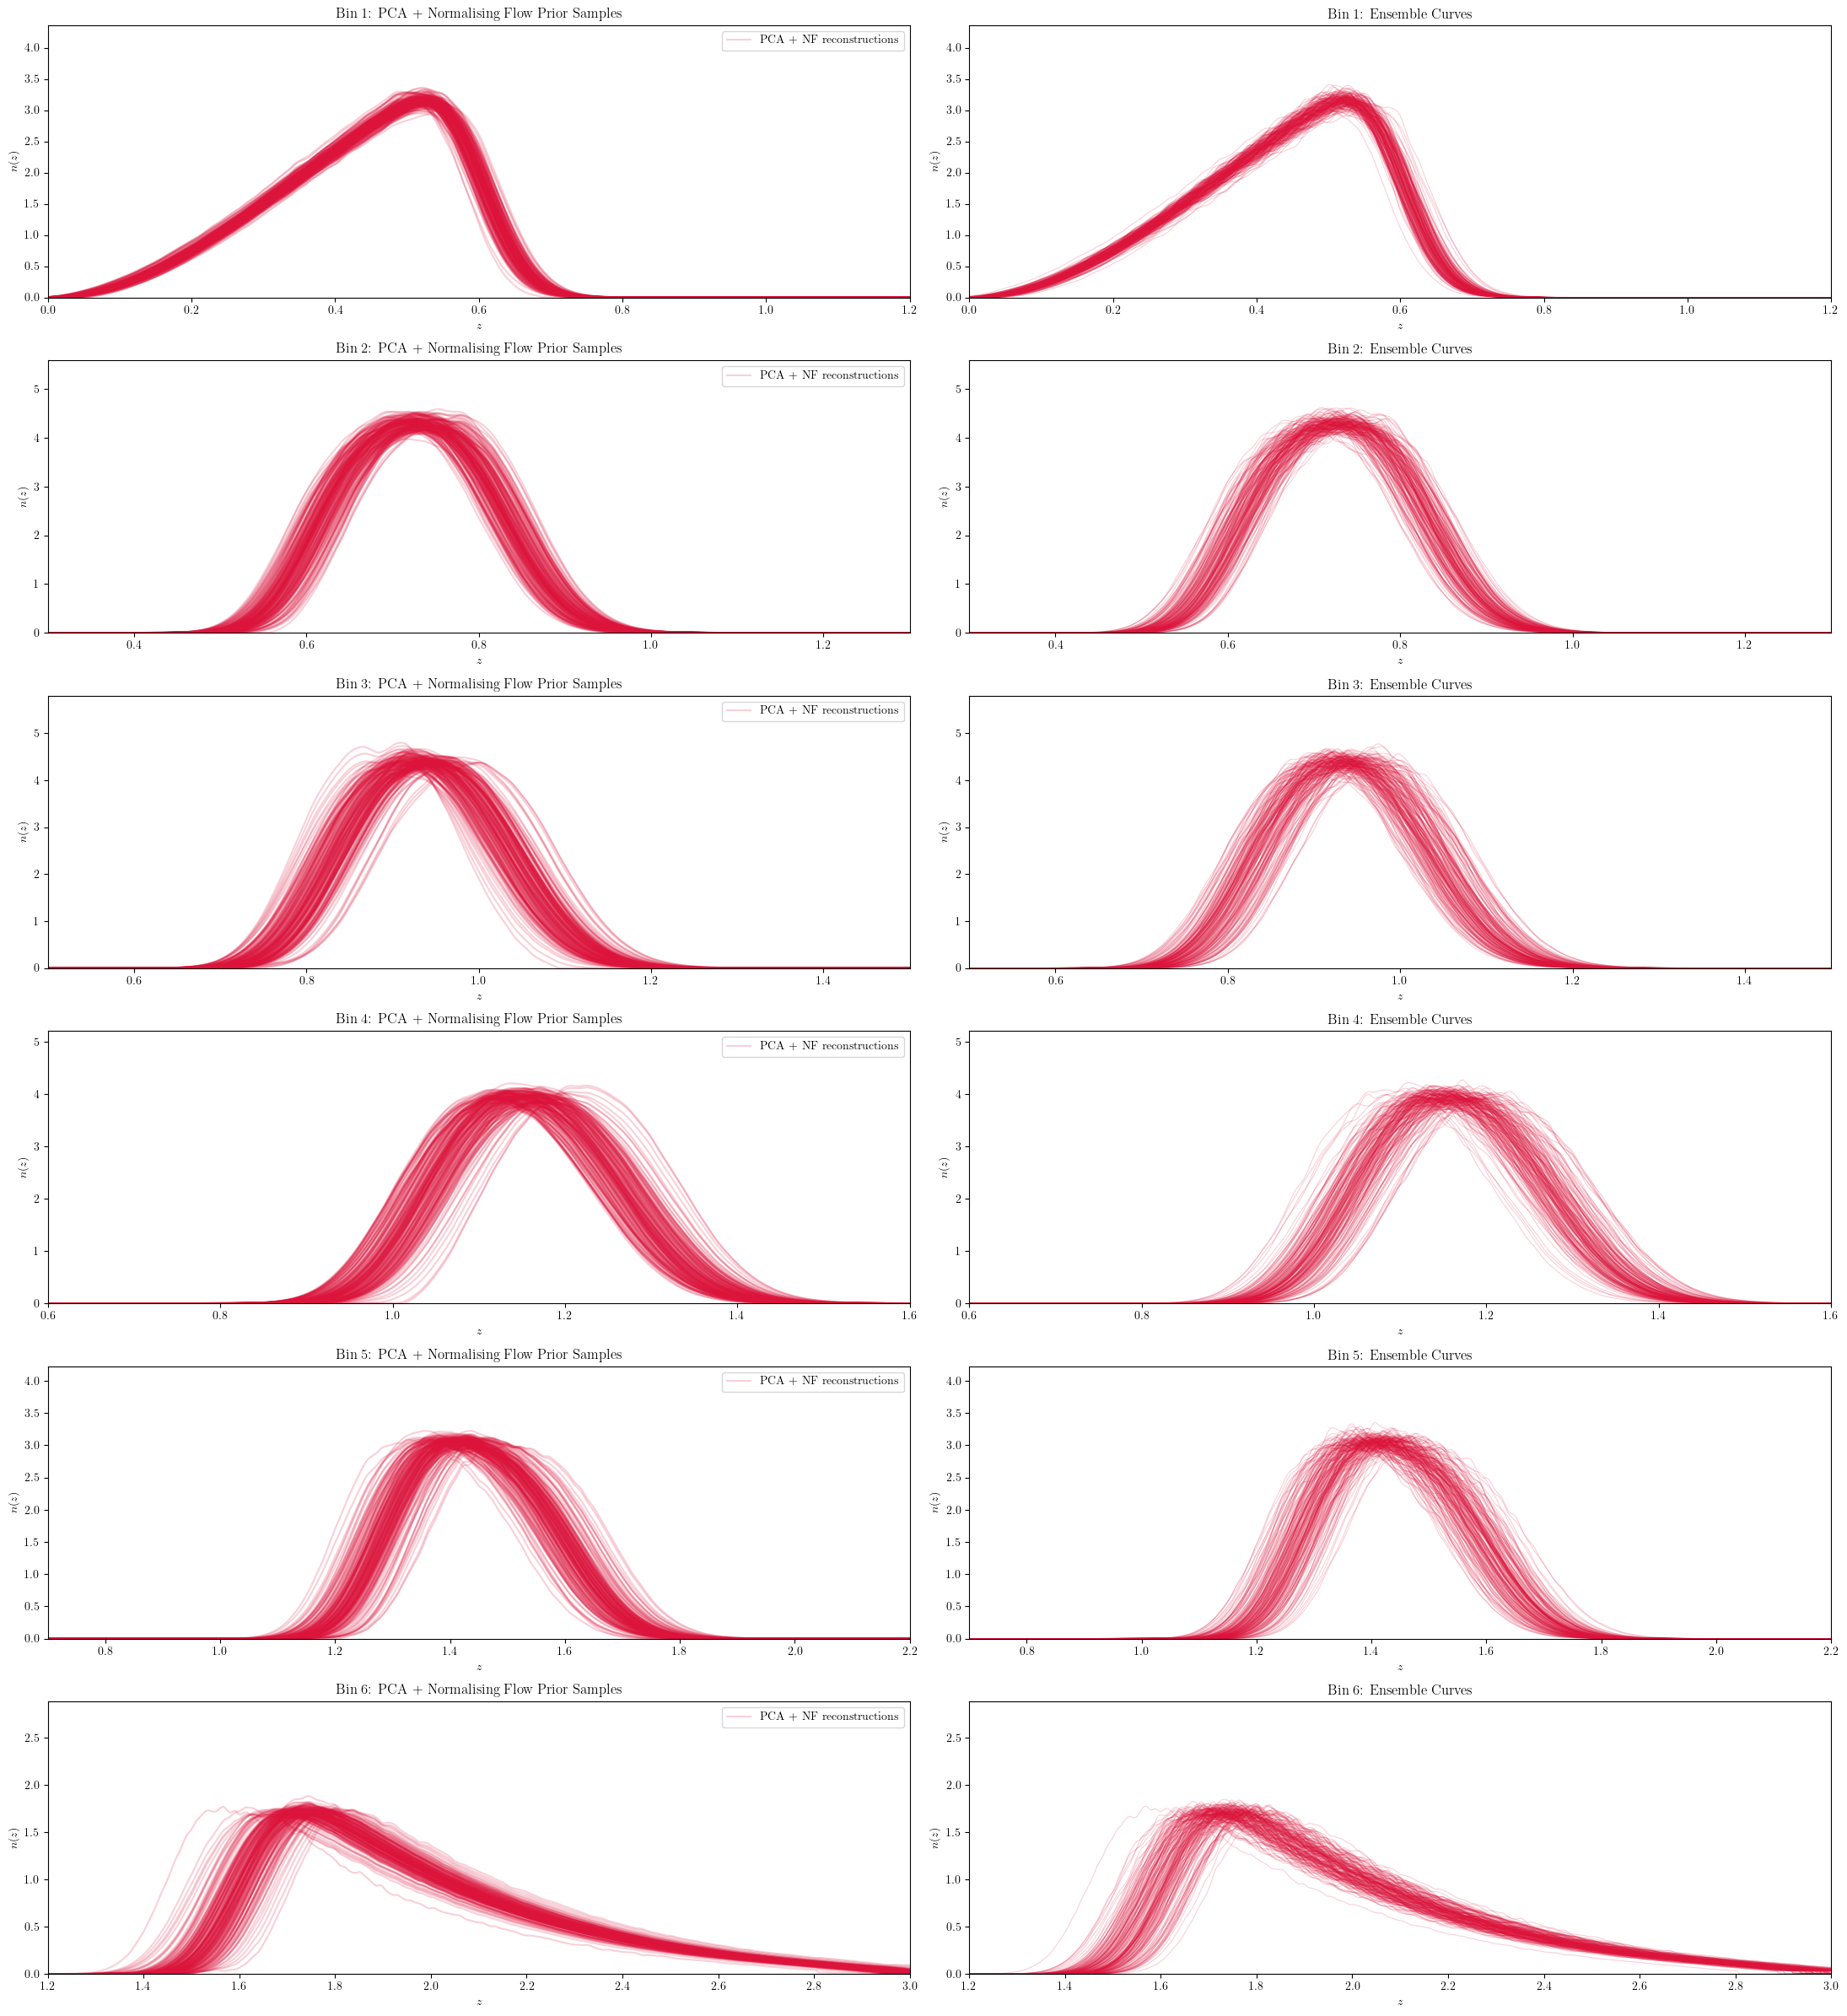

In [29]:
fig = plot_all_bins_pca(flows, means, stds, pcas, nz_ensemble_list, z_ens_list)

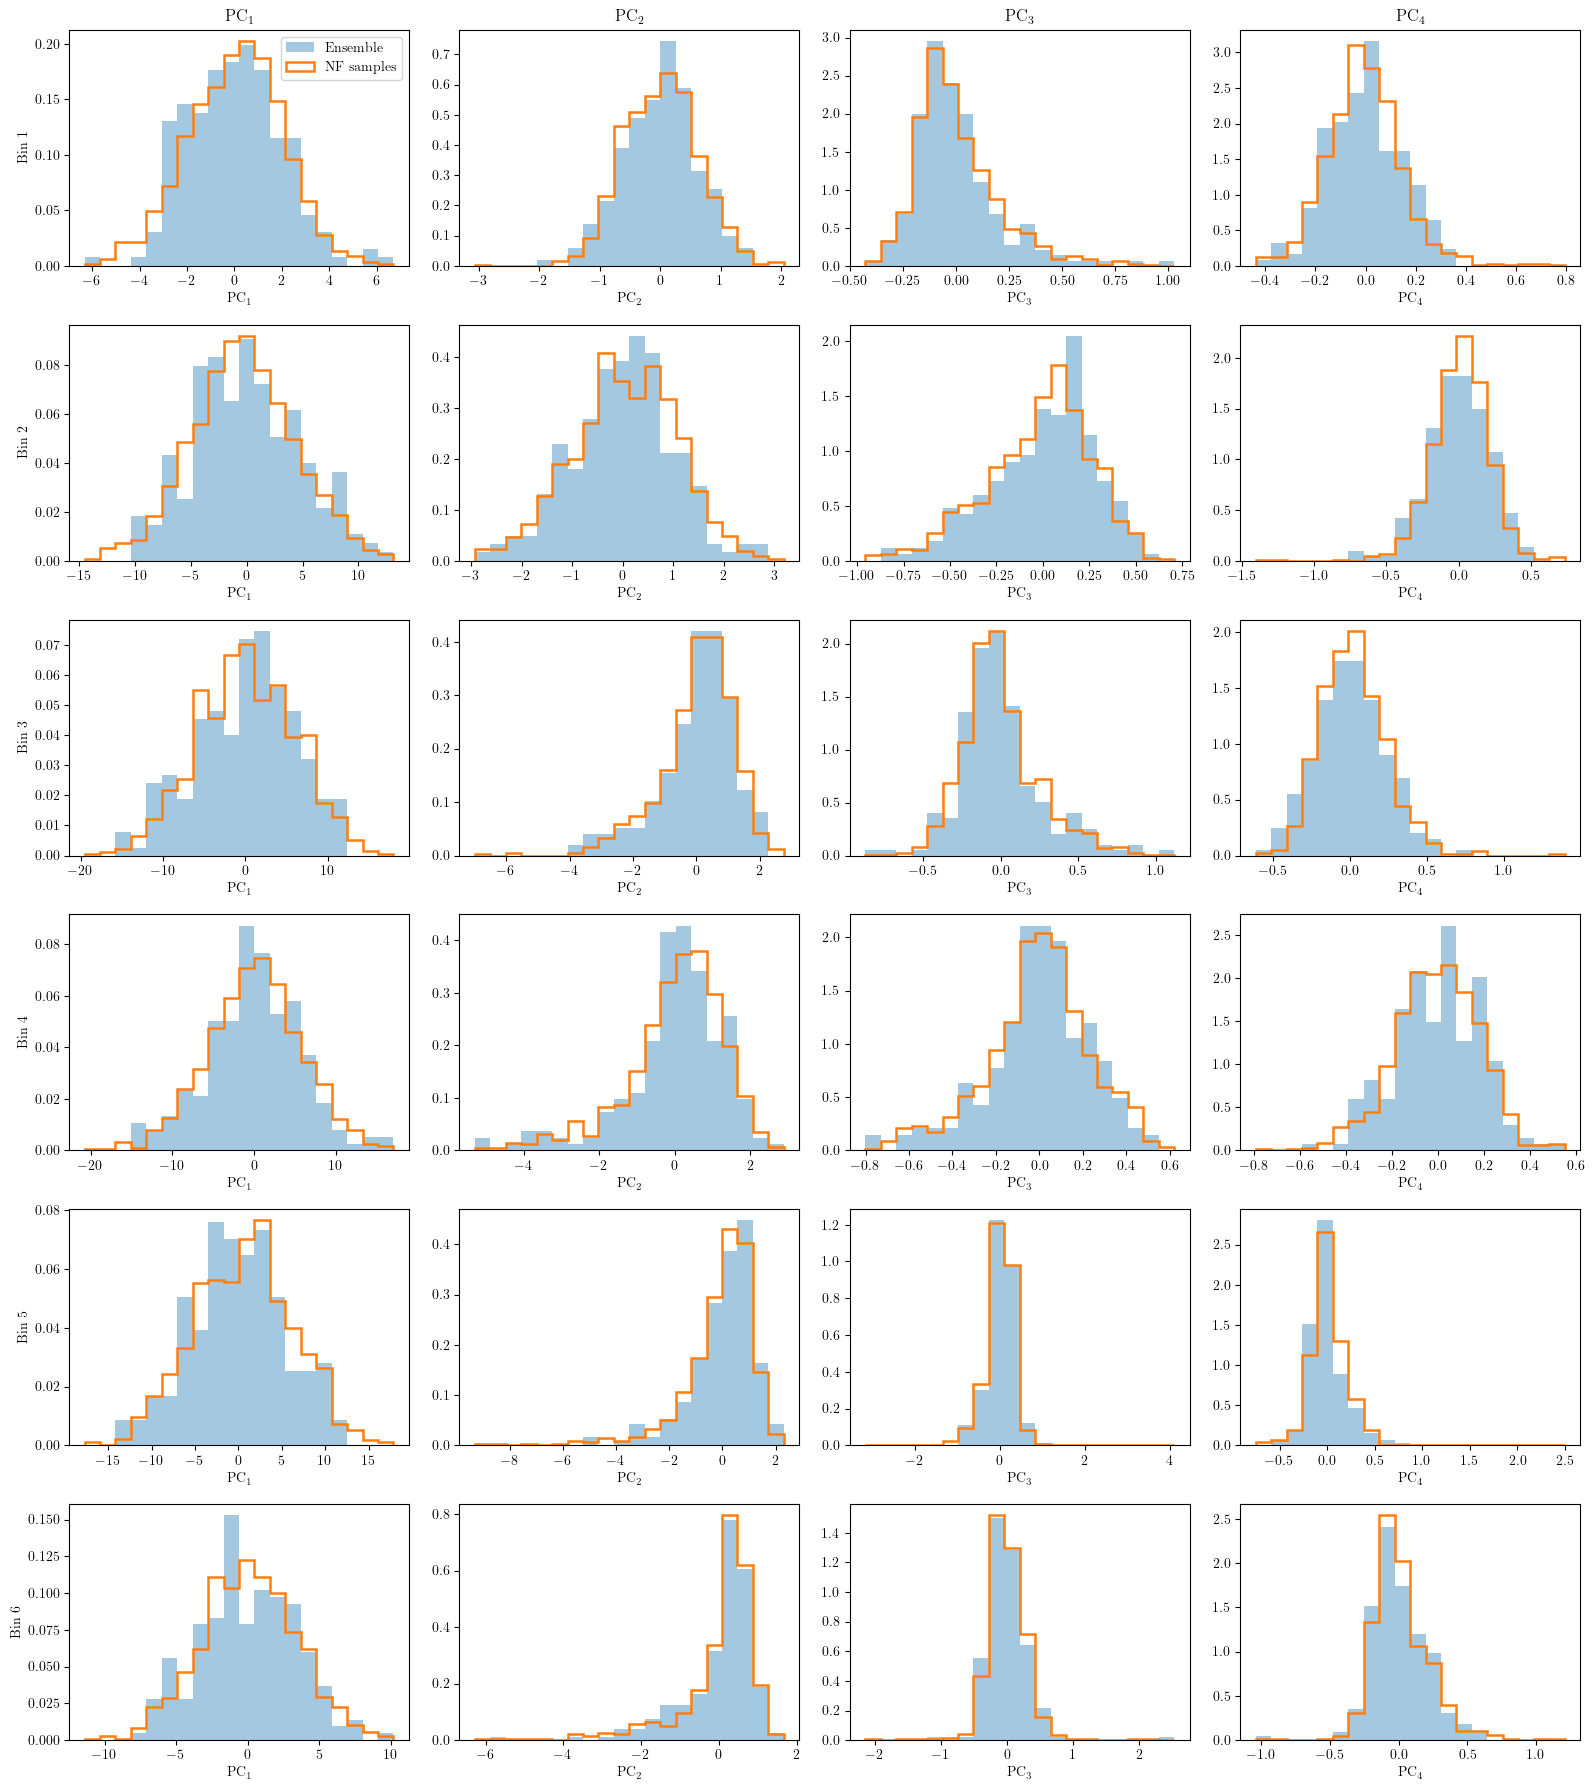

In [ ]:
fig, axes = plt.subplots(6, 4, figsize=(16, 18))

for b in range(6):
    pca_samples = pcas[b].transform(nz_ensemble_list[b])
    flow_samples_norm = flows[b].sample(1000).detach().numpy()
    flow_samples = flow_samples_norm * stds[b] + means[b]

    for i in range(4):
        bins = np.histogram_bin_edges(np.concatenate([pca_samples[:, i], flow_samples[:, i]]),bins=20)
        axes[b, i].hist(pca_samples[:, i], bins=bins, alpha=0.4, label="Ensemble",  density=True)
        axes[b, i].hist(flow_samples[:, i], bins=bins, histtype="step", linewidth=1.8, label="NF samples", density=True)
        axes[b, i].set_xlabel(fr"PC$_{i+1}$")
    axes[b, 0].set_ylabel(f"Bin {b+1}")
for i in range(4):
    axes[0, i].set_title(fr"PC$_{i+1}$")

axes[0, 0].legend()

plt.tight_layout()